# Assignment-1 - Variational Autoencoder: MNIST, Fashion-MNIST & Combined

| | |
|---|---|
| **Course:** | PROG74040 - Advanced Topics in Artificial Intelligence and Machine Learning |
| **Group Number:** | Group 5 |
| **Team members:** | Ansh, Henil, Kahan |

---

| Step | Description |
|------|-------------|
| 1 | Common setup: imports, configuration, data loading (shared across notebooks) |
| 2 | Dataset exploration and analysis (this notebook only) |
| 3 | Autoencoder model definition and helper functions |
| 4 | Train on MNIST, visualize latent space, generate images |
| 5 | Train on Fashion-MNIST, visualize latent space, generate images |
| 6 | Train on Combined dataset, visualize latent space, generate images |
| 7 | Reconstruction comparison and model saving |

## Importing libraries

In [12]:
# =========================
# Common Setup: Imports
# =========================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist, fashion_mnist

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Training configuration

In [13]:
# =========================
# Training Configuration
# =========================

BATCH_SIZE    = 128
EPOCHS        = 20
LEARNING_RATE = 1e-3
LATENT_DIM    = 2      # 2 enables 2D latent space scatter plots
GRID_SIZE     = 15     # grid dimension for generated images

print(f"Batch size    : {BATCH_SIZE}")
print(f"Epochs        : {EPOCHS}")
print(f"Learning rate : {LEARNING_RATE}")
print(f"Latent dim    : {LATENT_DIM}")
print(f"Grid size     : {GRID_SIZE}")

Batch size    : 128
Epochs        : 20
Learning rate : 0.001
Latent dim    : 2
Grid size     : 15


## Loading and preprocessing data

In [14]:
# =========================
# Data Loading and Preprocessing
# =========================

# Load MNIST
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Load Fashion-MNIST
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = fashion_mnist.load_data()

# Class name lookups
mnist_classes = [str(i) for i in range(10)]

fmnist_classes = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

combined_class_names = [f"D:{c}" for c in mnist_classes] + [f"F:{c}" for c in fmnist_classes]

# Normalize images from [0, 255] to [0, 1]
# This matches PyTorch transforms.ToTensor() in the vanilla notebook.
x_train_mnist = x_train_mnist.astype("float32") / 255.0
x_test_mnist  = x_test_mnist.astype("float32") / 255.0

x_train_fashion = x_train_fashion.astype("float32") / 255.0
x_test_fashion  = x_test_fashion.astype("float32") / 255.0

# Flatten images from 28x28 into 784 values for Dense-layer VAE input
x_train_mnist = x_train_mnist.reshape(-1, 784)
x_test_mnist  = x_test_mnist.reshape(-1, 784)

x_train_fashion = x_train_fashion.reshape(-1, 784)
x_test_fashion  = x_test_fashion.reshape(-1, 784)

# Combined training and test datasets
x_train_combined = np.concatenate([x_train_mnist, x_train_fashion], axis=0)
x_test_combined  = np.concatenate([x_test_mnist, x_test_fashion], axis=0)

# Labels for individual datasets remain 0-9
# For combined visualization, Fashion-MNIST labels are shifted to 10-19
y_train_combined = np.concatenate([y_train_mnist, y_train_fashion + 10], axis=0)
y_test_combined  = np.concatenate([y_test_mnist, y_test_fashion + 10], axis=0)

print(f"MNIST         - train: {len(x_train_mnist):,}  |  test: {len(x_test_mnist):,}")
print(f"Fashion-MNIST - train: {len(x_train_fashion):,}  |  test: {len(x_test_fashion):,}")
print(f"Combined      - train: {len(x_train_combined):,} |  test: {len(x_test_combined):,}")

print("\nShapes:")
print("x_train_mnist     :", x_train_mnist.shape)
print("x_train_fashion   :", x_train_fashion.shape)
print("x_train_combined  :", x_train_combined.shape)
print("y_train_combined  :", y_train_combined.shape)

MNIST         - train: 60,000  |  test: 10,000
Fashion-MNIST - train: 60,000  |  test: 10,000
Combined      - train: 120,000 |  test: 20,000

Shapes:
x_train_mnist     : (60000, 784)
x_train_fashion   : (60000, 784)
x_train_combined  : (120000, 784)
y_train_combined  : (120000,)


## Sampling layer 

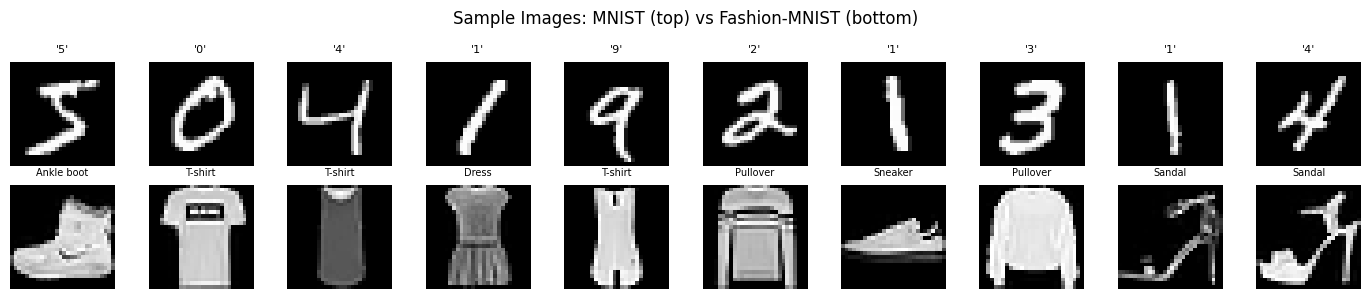

In [15]:
# =========================
# Sample Images: MNIST vs Fashion-MNIST
# =========================

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
fig.suptitle("Sample Images: MNIST (top) vs Fashion-MNIST (bottom)", fontsize=12)

for i in range(10):
    # MNIST sample
    axes[0, i].imshow(x_train_mnist[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title(f"'{mnist_classes[y_train_mnist[i]]}'", fontsize=8)
    axes[0, i].axis("off")

    # Fashion-MNIST sample
    axes[1, i].imshow(x_train_fashion[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title(fmnist_classes[y_train_fashion[i]], fontsize=7)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("MNIST", fontsize=9)
axes[1, 0].set_ylabel("Fashion", fontsize=9)

plt.tight_layout()
plt.show()

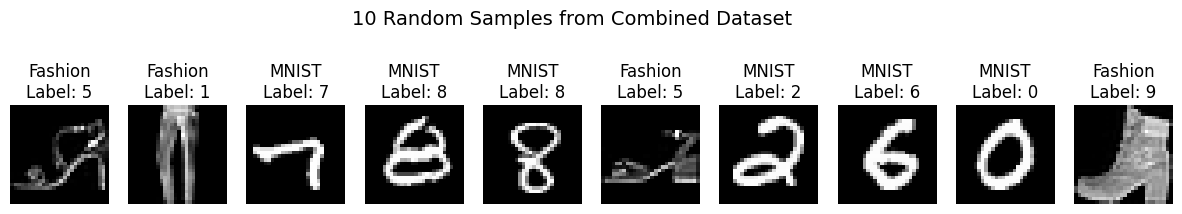

In [16]:


random_indices = np.random.choice(len(x_train_combined), size=10, replace=False)

plt.figure(figsize=(15, 3))

for plot_index, data_index in enumerate(random_indices):
    plt.subplot(1, 10, plot_index + 1)

    image = x_train_combined[data_index].reshape(28, 28)
    label = y_train_combined[data_index]
# 
    if label < 10:
        dataset_name = "MNIST"
        class_label = label
    else:
        dataset_name = "Fashion"
        class_label = label - 10

    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title(f"{dataset_name}\nLabel: {class_label}")

plt.suptitle("10 Random Samples from Combined Dataset", fontsize=14)
plt.show()

## Class distribution

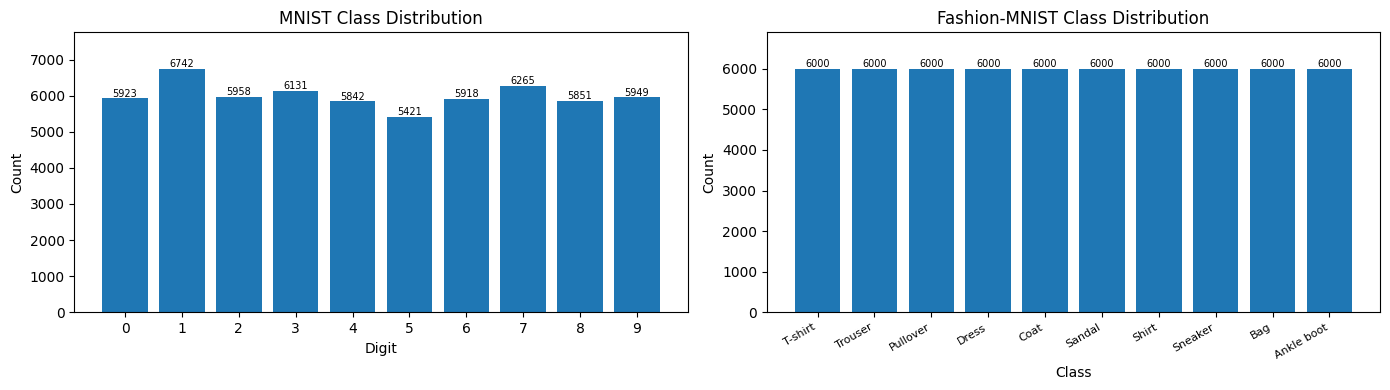

MNIST         - min class: 5,421  max class: 6,742
Fashion-MNIST - min class: 6,000  max class: 6,000


In [17]:
# =========================
# Class Distribution
# =========================

mnist_counts = [(y_train_mnist == i).sum() for i in range(10)]
fmnist_counts = [(y_train_fashion == i).sum() for i in range(10)]

x = range(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# MNIST distribution
axes[0].bar(x, mnist_counts)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(mnist_classes)
axes[0].set_title("MNIST Class Distribution")
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, max(mnist_counts) * 1.15)

for i, v in enumerate(mnist_counts):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=7)

# Fashion-MNIST distribution
axes[1].bar(x, fmnist_counts)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(fmnist_classes, rotation=30, ha="right", fontsize=8)
axes[1].set_title("Fashion-MNIST Class Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, max(fmnist_counts) * 1.15)

for i, v in enumerate(fmnist_counts):
    axes[1].text(i, v + 50, str(v), ha="center", fontsize=7)

plt.tight_layout()
plt.show()

print(f"MNIST         - min class: {min(mnist_counts):,}  max class: {max(mnist_counts):,}")
print(f"Fashion-MNIST - min class: {min(fmnist_counts):,}  max class: {max(fmnist_counts):,}")

## Encoder

In [18]:
# Custom Sampling layer for VAE
# This layer creates the actual latent vector z using z_mean and z_log_var

class Sampling(layers.Layer):
    def call(self, inputs):
        # Unpack mean and log variance from encoder output
        z_mean, z_log_var = inputs

        # Create random noise with same shape as z_mean
        epsilon = tf.random.normal(shape=tf.shape(z_mean))

        # Convert log variance to standard deviation
        z_std = tf.exp(0.5 * z_log_var)

        # Reparameterization trick:
        # z = mean + standard deviation * random noise
        z = z_mean + z_std * epsilon

        return z

In [19]:
# the latent dimension controls how small the compressed representation will be. 
# This allows us to plot each image as a point on a 2D graph. 
latent_dim = LATENT_DIM
# Encoder
encoder_inputs = layers.Input(shape =(784,))
x = layers.Dense(512, activation = "relu")(encoder_inputs)
x = layers.Dense(256, activation = "relu")(x) 
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
# z_mean gives the center point of the image in the latent space. 
z_mean = layers.Dense(latent_dim, name="z_mean")(x)

#z_log_var gives the spread/uncertainty around that center point
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

#Sampling layer creates the actual latent vector z 
z = Sampling()([z_mean, z_log_var])

# creating encoder model 
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    401,920 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    131,328 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 534,276 (2.04 MB)

 Trainable params: 534,276 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## Decoder

In [20]:
# Decoder inputt gets the sampled latent vector z
latent_inputs = layers.Input(shape=(latent_dim,), name="decoder_input")

#Expanding 2D latent vector into a larger hidden representation
x = layers.Dense(256, activation="relu")(latent_inputs)

#Expanding further
x = layers.Dense(512, activation="relu")(x)

#Final output of decoder has 784 values as the original input value is 28x28
#signmoid keeps output pixel values between 0 and 1 
decoder_outputs = layers.Dense(784, activation="sigmoid")(x) 

#Creating decoder model
decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 534,544 (2.04 MB)

 Trainable params: 534,544 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## Creating a VAE model class

In [21]:
class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()

        # Store encoder and decoder inside one VAE model
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        # Encoder produces mean, log variance, and sampled z
        z_mean, z_log_var, z = self.encoder(inputs)

        # Decoder reconstructs image from z
        reconstructed = self.decoder(z)

        return reconstructed

## Defining VAE loss 



In [22]:
def compute_vae_loss (x_original, x_reconstructed, z_mean, z_log_var):
    #Reconstruction loss checks how close output image is to input image
    reconstruction_loss = tf.keras.backend.binary_crossentropy(x_original, x_reconstructed)

    # Sum loss across 784 pixels 
    reconstruction_loss = tf.reduce_sum(reconstruction_loss, axis=1)

    # Avg over batch
    reconstruction_loss = tf.reduce_mean(reconstruction_loss)

    # KL loss forces latent space to stay smooth and close to normal distribution
    kl_loss = -0.5 * tf.reduce_sum(1+z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
    
    # Avg over batch
    kl_loss = tf.reduce_mean(kl_loss)

    # Total VAE loss
    total_loss = reconstruction_loss + kl_loss
    return total_loss, reconstruction_loss, kl_loss

## function that will build a fresh VAE

In [23]:
def build_vae(latent_dim=LATENT_DIM):

    # Encoder
    # Input layer: each image is flattened from 28x28 into 784 values
    encoder_inputs = layers.Input(shape=(784,), name="encoder_input")

    # First hidden layer of encoder
    x = layers.Dense(512, activation="relu")(encoder_inputs)

    # Second hidden layer of encoder
    x = layers.Dense(256, activation="relu")(x)

    # Mean of the latent distribution
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)

    # Log variance of the latent distribution
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

    # Sample one latent vector z using mean and log variance
    z = Sampling()([z_mean, z_log_var])

    # Encoder model returns mean, log variance, and sampled z
    encoder = Model(
        encoder_inputs,
        [z_mean, z_log_var, z],
        name="encoder"
    )

    # Decoder

    # Decoder input: sampled latent vector with 2 values
    latent_inputs = layers.Input(shape=(latent_dim,), name="decoder_input")

    # First hidden layer of decoder
    x = layers.Dense(256, activation="relu")(latent_inputs)

    # Second hidden layer of decoder
    x = layers.Dense(512, activation="relu")(x)

    # Output layer: reconstruct 784 pixel values
    decoder_outputs = layers.Dense(784, activation="sigmoid")(x)

    # Decoder model converts latent vector back into image
    decoder = Model(
        latent_inputs,
        decoder_outputs,
        name="decoder"
    )

    # Full VAE model
    vae = VAE(encoder, decoder)

    return vae, encoder, decoder

## Training function

In [24]:
def train_vae_model(x_train, epochs=20, batch_size=128, learning_rate=0.001):
    # Build fresh VAE
    vae, encoder, decoder = build_vae(latent_dim=2)

    # Adam optimizer updates model weights
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Create TensorFlow dataset
    dataset = tf.data.Dataset.from_tensor_slices(x_train)
    dataset = dataset.shuffle(buffer_size=10000).batch(batch_size)

    # Store loss values
    total_loss_history = []
    reconstruction_loss_history = []
    kl_loss_history = []

    for epoch in range(epochs):
        epoch_total_loss = 0
        epoch_reconstruction_loss = 0
        epoch_kl_loss = 0
        batch_count = 0

        for batch in dataset:
            with tf.GradientTape() as tape:
                # Encode image batch
                z_mean, z_log_var, z = encoder(batch)

                # Decode sampled latent vector
                reconstructed = decoder(z)

                # Compute loss
                total_loss, reconstruction_loss, kl_loss = compute_vae_loss(
                    batch,
                    reconstructed,
                    z_mean,
                    z_log_var
                )

            # Calculate gradients
            gradients = tape.gradient(total_loss, vae.trainable_weights)

            # Update weights
            optimizer.apply_gradients(zip(gradients, vae.trainable_weights))

            epoch_total_loss += total_loss.numpy()
            epoch_reconstruction_loss += reconstruction_loss.numpy()
            epoch_kl_loss += kl_loss.numpy()
            batch_count += 1

        avg_total_loss = epoch_total_loss / batch_count
        avg_reconstruction_loss = epoch_reconstruction_loss / batch_count
        avg_kl_loss = epoch_kl_loss / batch_count

        total_loss_history.append(avg_total_loss)
        reconstruction_loss_history.append(avg_reconstruction_loss)
        kl_loss_history.append(avg_kl_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Total Loss: {avg_total_loss:.4f} | "
            f"Reconstruction Loss: {avg_reconstruction_loss:.4f} | "
            f"KL Loss: {avg_kl_loss:.4f}"
        )

    history = {
        "total_loss": total_loss_history,
        "reconstruction_loss": reconstruction_loss_history,
        "kl_loss": kl_loss_history
    }

    return vae, encoder, decoder, history

## training on mnist dataset 


In [25]:
vae_mnist, encoder_mnist, decoder_mnist, history_mnist = train_vae_model(
    x_train_mnist,
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE
)

Epoch 1/20 | Total Loss: 185.3545 | Reconstruction Loss: 180.0078 | KL Loss: 5.3467
Epoch 2/20 | Total Loss: 163.0338 | Reconstruction Loss: 158.0625 | KL Loss: 4.9713
Epoch 3/20 | Total Loss: 157.9083 | Reconstruction Loss: 152.5651 | KL Loss: 5.3432
Epoch 4/20 | Total Loss: 154.5198 | Reconstruction Loss: 148.8996 | KL Loss: 5.6202
Epoch 5/20 | Total Loss: 151.8169 | Reconstruction Loss: 145.9812 | KL Loss: 5.8356
Epoch 6/20 | Total Loss: 149.8490 | Reconstruction Loss: 143.8758 | KL Loss: 5.9732
Epoch 7/20 | Total Loss: 148.2868 | Reconstruction Loss: 142.1760 | KL Loss: 6.1109
Epoch 8/20 | Total Loss: 147.0550 | Reconstruction Loss: 140.8808 | KL Loss: 6.1742
Epoch 9/20 | Total Loss: 146.1197 | Reconstruction Loss: 139.8812 | KL Loss: 6.2385
Epoch 10/20 | Total Loss: 145.2618 | Reconstruction Loss: 138.9787 | KL Loss: 6.2831
Epoch 11/20 | Total Loss: 144.5119 | Reconstruction Loss: 138.1748 | KL Loss: 6.3371
Epoch 12/20 | Total Loss: 143.8454 | Reconstruction Loss: 137.4721 | KL Lo

## training on fashion mnist


In [26]:
vae_fashion, encoder_fashion, decoder_fashion, history_fashion = train_vae_model(
    x_train_fashion,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE
)

Epoch 1/20 | Total Loss: 295.7934 | Reconstruction Loss: 289.5924 | KL Loss: 6.2010
Epoch 2/20 | Total Loss: 270.8297 | Reconstruction Loss: 264.7475 | KL Loss: 6.0823
Epoch 3/20 | Total Loss: 266.7542 | Reconstruction Loss: 260.6395 | KL Loss: 6.1146
Epoch 4/20 | Total Loss: 264.6541 | Reconstruction Loss: 258.5394 | KL Loss: 6.1147
Epoch 5/20 | Total Loss: 263.3722 | Reconstruction Loss: 257.2179 | KL Loss: 6.1546
Epoch 6/20 | Total Loss: 262.3448 | Reconstruction Loss: 256.1684 | KL Loss: 6.1764
Epoch 7/20 | Total Loss: 261.3758 | Reconstruction Loss: 255.1562 | KL Loss: 6.2195
Epoch 8/20 | Total Loss: 260.6774 | Reconstruction Loss: 254.4230 | KL Loss: 6.2545
Epoch 9/20 | Total Loss: 259.8804 | Reconstruction Loss: 253.5951 | KL Loss: 6.2850
Epoch 10/20 | Total Loss: 259.5009 | Reconstruction Loss: 253.1963 | KL Loss: 6.3045
Epoch 11/20 | Total Loss: 258.8886 | Reconstruction Loss: 252.5544 | KL Loss: 6.3341
Epoch 12/20 | Total Loss: 258.4894 | Reconstruction Loss: 252.1340 | KL Lo

## training on combined dataset

In [27]:
vae_combined, encoder_combined, decoder_combined, history_combined = train_vae_model(
    x_train_combined,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE
)   

Epoch 1/20 | Total Loss: 241.7241 | Reconstruction Loss: 236.0147 | KL Loss: 5.7094
Epoch 2/20 | Total Loss: 225.3123 | Reconstruction Loss: 219.5139 | KL Loss: 5.7987
Epoch 3/20 | Total Loss: 220.1410 | Reconstruction Loss: 214.0696 | KL Loss: 6.0713
Epoch 4/20 | Total Loss: 216.9622 | Reconstruction Loss: 210.6854 | KL Loss: 6.2768
Epoch 5/20 | Total Loss: 214.0935 | Reconstruction Loss: 207.6802 | KL Loss: 6.4131
Epoch 6/20 | Total Loss: 212.1628 | Reconstruction Loss: 205.6263 | KL Loss: 6.5365
Epoch 7/20 | Total Loss: 210.6647 | Reconstruction Loss: 203.9893 | KL Loss: 6.6753
Epoch 8/20 | Total Loss: 208.9118 | Reconstruction Loss: 202.1948 | KL Loss: 6.7168
Epoch 9/20 | Total Loss: 208.5401 | Reconstruction Loss: 201.7687 | KL Loss: 6.7712
Epoch 10/20 | Total Loss: 207.9203 | Reconstruction Loss: 201.1085 | KL Loss: 6.8119
Epoch 11/20 | Total Loss: 206.7059 | Reconstruction Loss: 199.8360 | KL Loss: 6.8700
Epoch 12/20 | Total Loss: 206.2892 | Reconstruction Loss: 199.3740 | KL Lo

## plotting training loss   



In [28]:
import matplotlib.pyplot as plt

def plot_training_loss(history, title):
    plt.figure(figsize=(8, 5))

    plt.plot(history["total_loss"], label="Total Loss")
    plt.plot(history["reconstruction_loss"], label="Reconstruction Loss")
    plt.plot(history["kl_loss"], label="KL Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

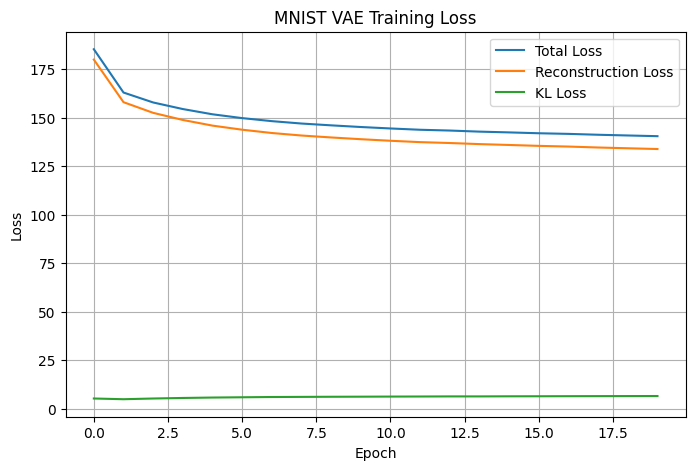

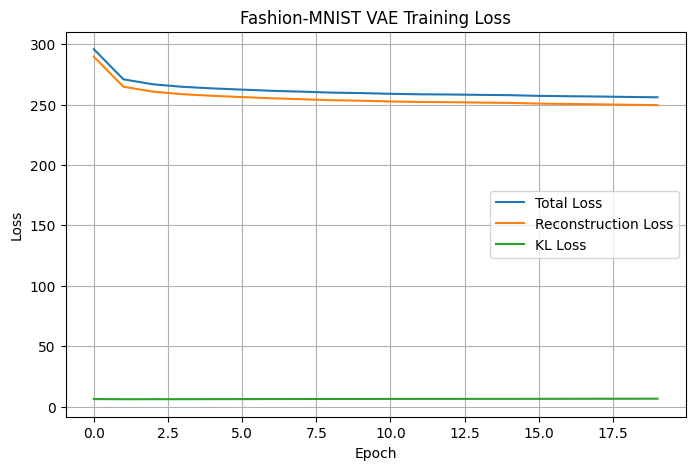

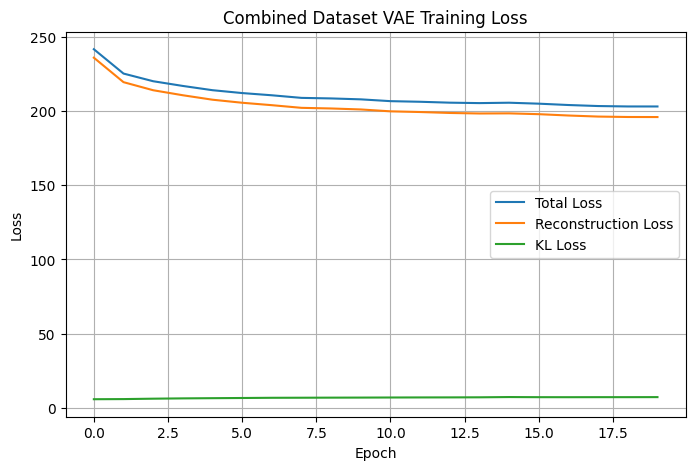

In [29]:
plot_training_loss(history_mnist, "MNIST VAE Training Loss")
plot_training_loss(history_fashion, "Fashion-MNIST VAE Training Loss")
plot_training_loss(history_combined, "Combined Dataset VAE Training Loss")

In [30]:
def show_combined_reconstructions_mixed(
    encoder,
    decoder,
    x_test_combined,
    y_test_combined,
    n_mnist=5,
    n_fashion=5
):
    """
    Shows mixed original vs reconstructed images from the combined dataset.
    This avoids only showing MNIST digits from the beginning of x_test_combined.
    """

    # Select MNIST samples from combined labels.
    # In the combined dataset, MNIST labels are 0-9.
    mnist_indices = np.where(y_test_combined < 10)[0][:n_mnist]

    # Select Fashion-MNIST samples from combined labels.
    # In the combined dataset, Fashion-MNIST labels are 10-19.
    fashion_indices = np.where(y_test_combined >= 10)[0][:n_fashion]

    # Combine selected MNIST and Fashion-MNIST indices.
    selected_indices = np.concatenate([mnist_indices, fashion_indices])

    # Get selected images and labels.
    sample_images = x_test_combined[selected_indices]
    sample_labels = y_test_combined[selected_indices]

    # Pass images through encoder.
    z_mean, z_log_var, z = encoder.predict(sample_images)

    # Reconstruct images using decoder.
    reconstructed_images = decoder.predict(z)

    # Total number of displayed images.
    total_images = len(sample_images)

    # Fashion-MNIST class names.
    fashion_class_names = [
        "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
        "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
    ]

    plt.figure(figsize=(18, 4))

    for i in range(total_images):
        label = sample_labels[i]

        # Create readable label.
        if label < 10:
            label_name = f"Digit {label}"
        else:
            fashion_label = label - 10
            label_name = fashion_class_names[fashion_label]

        # Original image
        plt.subplot(2, total_images, i + 1)
        plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"Original\n{label_name}", fontsize=9)

        # Reconstructed image
        plt.subplot(2, total_images, i + 1 + total_images)
        plt.imshow(reconstructed_images[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title("Recon", fontsize=9)

    plt.suptitle("Combined Dataset: Mixed MNIST + Fashion-MNIST Reconstructions")
    plt.tight_layout()
    plt.show()

## showing original vs reconstructed images


In [31]:
def show_reconstructions(encoder, decoder, x_test, title, n=10):
    # Take first n images from test set
    sample_images = x_test[:n]

    # Encode images into latent space
    z_mean, z_log_var, z = encoder.predict(sample_images)

    # Decode sampled z back into reconstructed images
    reconstructed_images = decoder.predict(z)

    plt.figure(figsize=(18, 4))

    for i in range(n):
        # Original image
        plt.subplot(2, n, i + 1)
        plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title("Original")

        # Reconstructed image
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed_images[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title("Recon")

    plt.suptitle(title)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


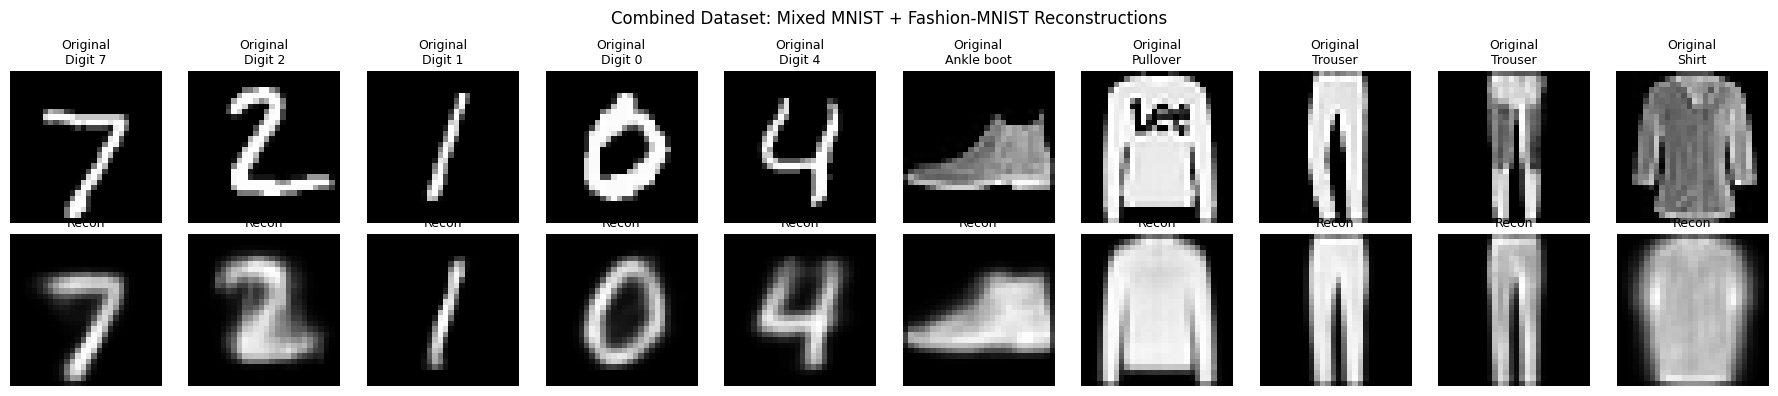

In [32]:
show_combined_reconstructions_mixed(
    encoder_combined,
    decoder_combined,
    x_test_combined,
    y_test_combined,
    n_mnist=5,
    n_fashion=5
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


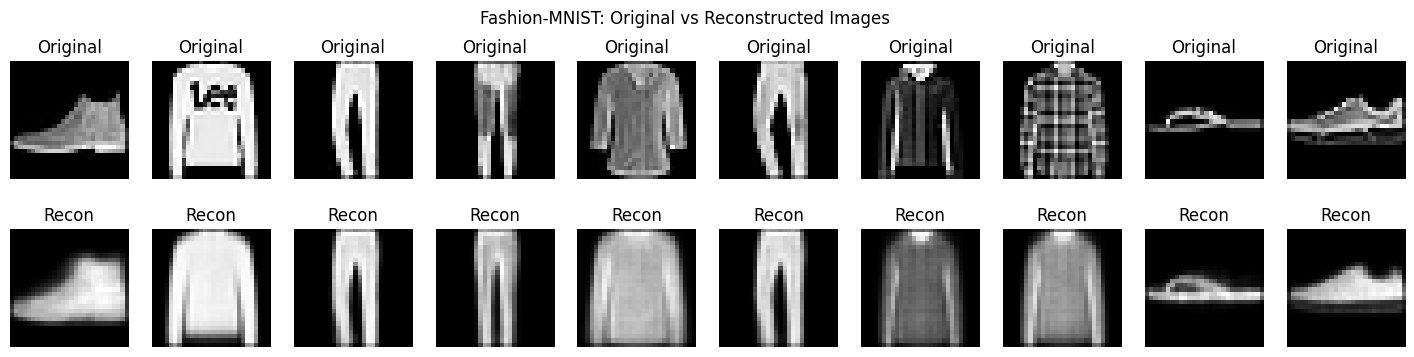

In [33]:
show_reconstructions(
    encoder_fashion,
    decoder_fashion,
    x_test_fashion,
    "Fashion-MNIST: Original vs Reconstructed Images"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


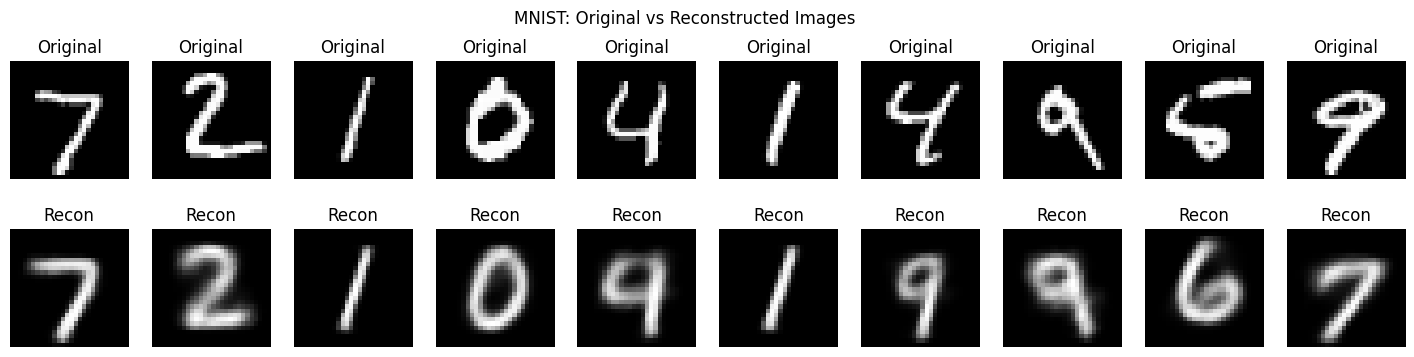

In [39]:
show_reconstructions(
    encoder_mnist,
    decoder_mnist,
    x_test_mnist,
    "MNIST: Original vs Reconstructed Images"
)

## visualizing latent space

In [35]:
def plot_latent_space(encoder, x_test, y_test, title):
    # Use z_mean because it represents the center location in latent space
    z_mean, z_log_var, z = encoder.predict(x_test)

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        z_mean[:, 0],
        z_mean[:, 1],
        c=y_test,
        cmap="tab20",
        s=5
    )

    plt.colorbar(scatter)
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.title(title)
    plt.grid(True)
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step


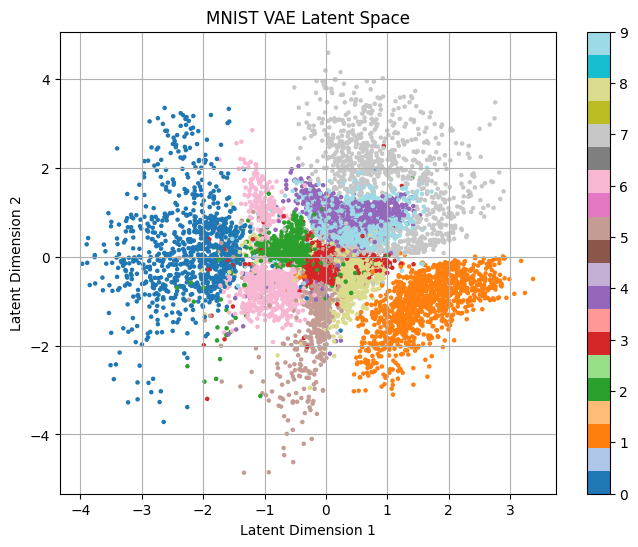

In [36]:
plot_latent_space(
    encoder_mnist,
    x_test_mnist,
    y_test_mnist,
    "MNIST VAE Latent Space"
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step


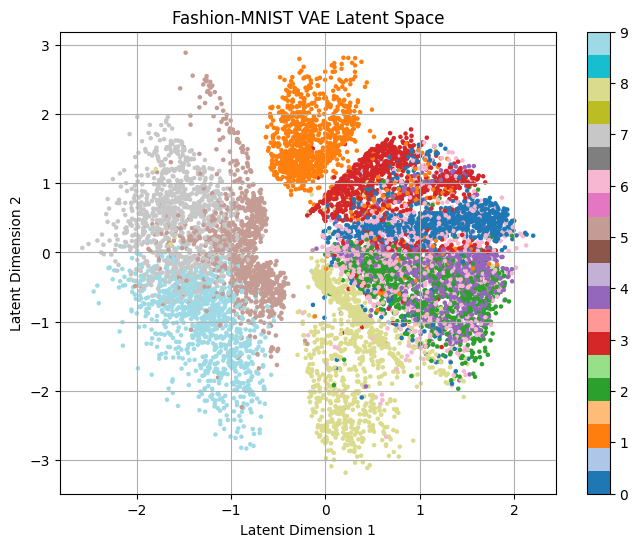

In [37]:
plot_latent_space(
    encoder_fashion,
    x_test_fashion,
    y_test_fashion,
    "Fashion-MNIST VAE Latent Space"
)

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step


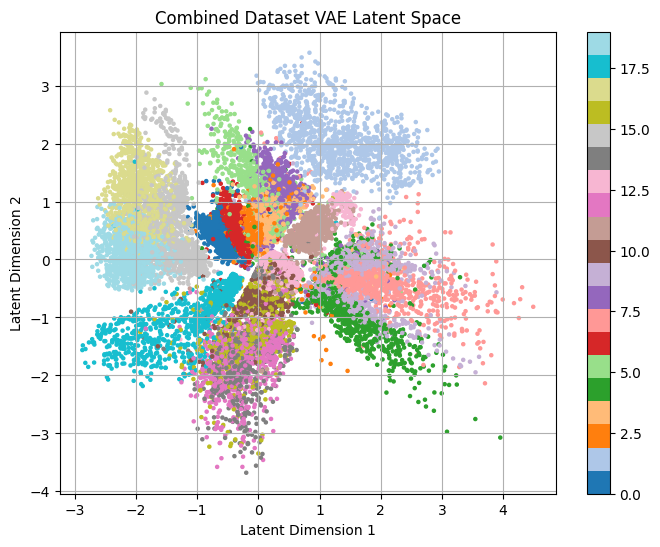

In [38]:
plot_latent_space(
    encoder_combined,
    x_test_combined,
    y_test_combined,
    "Combined Dataset VAE Latent Space"
)

## Summary

| Model | Dataset | Latent Dim | Training Epochs | Final Total Loss | Final Reconstruction Loss | Final KL Loss | Parameters |
|-------|---------|------------|-----------------|------------------|---------------------------|---------------|------------|
| `vae_mnist` | MNIST | 2 | 20 | 140.5374 | 133.9170 | 6.6203 | ~1.07M |
| `vae_fashion` | Fashion-MNIST | 2 | 20 | 256.0100 | 249.4905 | 6.5196 | ~1.07M |
| `vae_combined` | MNIST + Fashion-MNIST | 2 | 20 | 203.1170 | 195.9861 | 7.1307 | ~1.07M |

**Key takeaways:**
- The VAE uses a 2D latent space, so each image is compressed into two latent values that can be plotted and interpreted visually.
- Unlike a vanilla autoencoder, the VAE encoder learns `z_mean` and `z_log_var`, then samples a latent vector `z` using the reparameterization trick.
- The total VAE loss is made of two parts: reconstruction loss and KL divergence loss. Reconstruction loss measures how well the image is rebuilt, while KL loss keeps the latent space smooth and close to a normal distribution.
- MNIST achieved the lowest final loss because handwritten digits are visually simpler and more consistent.
- Fashion-MNIST had the highest final loss because clothing images have more shape and texture variation.
- The combined model produced a loss between MNIST and Fashion-MNIST because it had to learn both digit and clothing image distributions in the same latent space.
- The combined latent space is expected to show more overlap because the model is unsupervised and is organizing images by visual similarity, not by class labels.
- Increasing `LATENT_DIM` may improve reconstruction quality, but using `LATENT_DIM = 2` is useful because it allows direct 2D latent-space visualization.